In [6]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

In [7]:
wave_ds = xr.open_mfdataset(Path('..//data/8m_array_waves').glob('*.nc'))

In [8]:
wave_ds

<xarray.Dataset> Size: 42MB
Dimensions:                         (time: 2177, waveFrequency: 62,
                                     waveDirectionBins: 72)
Coordinates:
  * time                            (time) datetime64[ns] 17kB 2021-09-01 ......
  * waveFrequency                   (waveFrequency) float32 248B 0.04 ... 0.4975
  * waveDirectionBins               (waveDirectionBins) float32 288B 0.0 ... ...
Data variables: (12/28)
    station_name                    (time) |S12 26kB b'8m-Array' ... b'8m-Array'
    latitude                        (time) float64 17kB 36.19 36.19 ... 36.19
    longitude                       (time) float64 17kB 75.74 75.74 ... 75.74
    nominalDepth                    (time) float32 9kB 8.0 8.0 8.0 ... 8.0 8.0
    depth                           (time) float32 9kB dask.array<chunksize=(716,), meta=np.ndarray>
    gaugeDepth                      (time) float32 9kB dask.array<chunksize=(716,), meta=np.ndarray>
    ...                              ...
    waveA1Value                     (time, waveFrequency) float32 540kB dask.array<chunksize=(1, 62), meta=np.ndarray>
    waveB1Value                     (time, waveFrequency) float32 540kB dask.array<chunksize=(1, 62), meta=np.ndarray>
    waveA2Value                     (time, waveFrequency) float32 540kB dask.array<chunksize=(1, 62), meta=np.ndarray>
    waveB2Value                     (time, waveFrequency) float32 540kB dask.array<chunksize=(1, 62), meta=np.ndarray>
    waterLevel                      (time) float32 9kB dask.array<chunksize=(716,), meta=np.ndarray>
    airPressure                     (time) float32 9kB dask.array<chunksize=(716,), meta=np.ndarray>
Attributes: (12/57)
    featureType:                     timeSeries
    title:                           FRF 8m Array
    summary:                         USACE Coastal Observation and Analysis B...
    history:                         1991-01-01:dataset created
    source:                          In situ observations from FRF-ocean_wave...
    sourceUrl:                       (local files)
    ...                              ...
    cross_shore_angle_units:         degrees
    cross_shore_angle_description:   cross shore angle at the USACE FRF site ...
    cross_shore_angle:               71.8
    date_created:                    2021-09-30
    date_issued:                     2021-09-30
    time_coverage_end:               2021-09-30T20:00:00

In [ ]:
wave_ds.waveMeanDirection

Text(0, 0.5, 'Naive Onshore Energy Flux [W/m]')

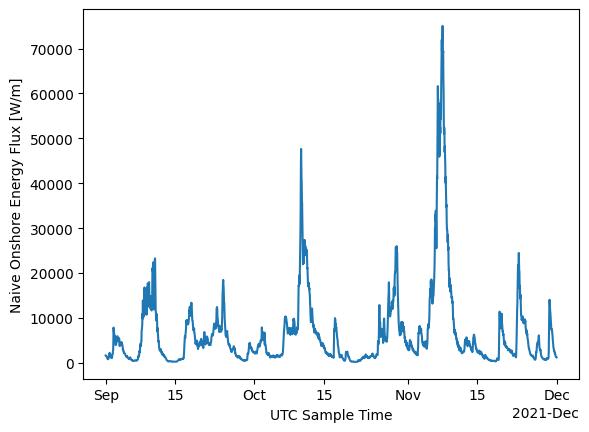

In [ ]:
# H_s = H_{m0} = 4 \sqrt{<E>/\rho g}
# E = (H_s/4)^2 \rho g
rho = 1025
g = 9.81
cross_shore_angle = 71.8  # degrees CW from true North — FRF offshore direction

# Naive energy flux magnitude: rho*g*(Hs/4)^2 * sqrt(g*h) (shallow-water cg)
F_naive_scalar = rho * g * (wave_ds.waveHs / 4)**2 * np.sqrt(g * 8)

# Project onto onshore direction using waveMeanDirection (MET convention: degrees CW from North, "coming from")
# Travel direction unit vector: n_east = -sin(theta), n_north = -cos(theta)
# Onshore unit vector (negative of offshore at 71.8° CW from N): n_east = -sin(shore_normal_rad), n_north = -cos(shore_normal_rad)
# Dot product = cos(theta_rad - shore_normal_rad_rad)
shore_normal_rad = np.deg2rad(cross_shore_angle)
theta_rad = np.deg2rad(wave_ds.waveMeanDirection)
naive_onshore_flux = F_naive_scalar * np.cos(theta_rad - shore_normal_rad)

naive_onshore_flux.plot()
plt.ylabel('Naive Onshore Energy Flux [W/m]')

<>:68: SyntaxWarning: invalid escape sequence '\%'
<>:68: SyntaxWarning: invalid escape sequence '\%'
/var/folders/xv/4vxt441n3tz_yllzvqvzmsgw0000gr/T/ipykernel_47297/2863888137.py:68: SyntaxWarning: invalid escape sequence '\%'
  axes[1].set_ylabel('\%diff')


Mean onshore flux (directional):  4073.7 W/m
Mean along-shore flux:            -282.5 W/m
Mean naive flux:                  6685.5 W/m


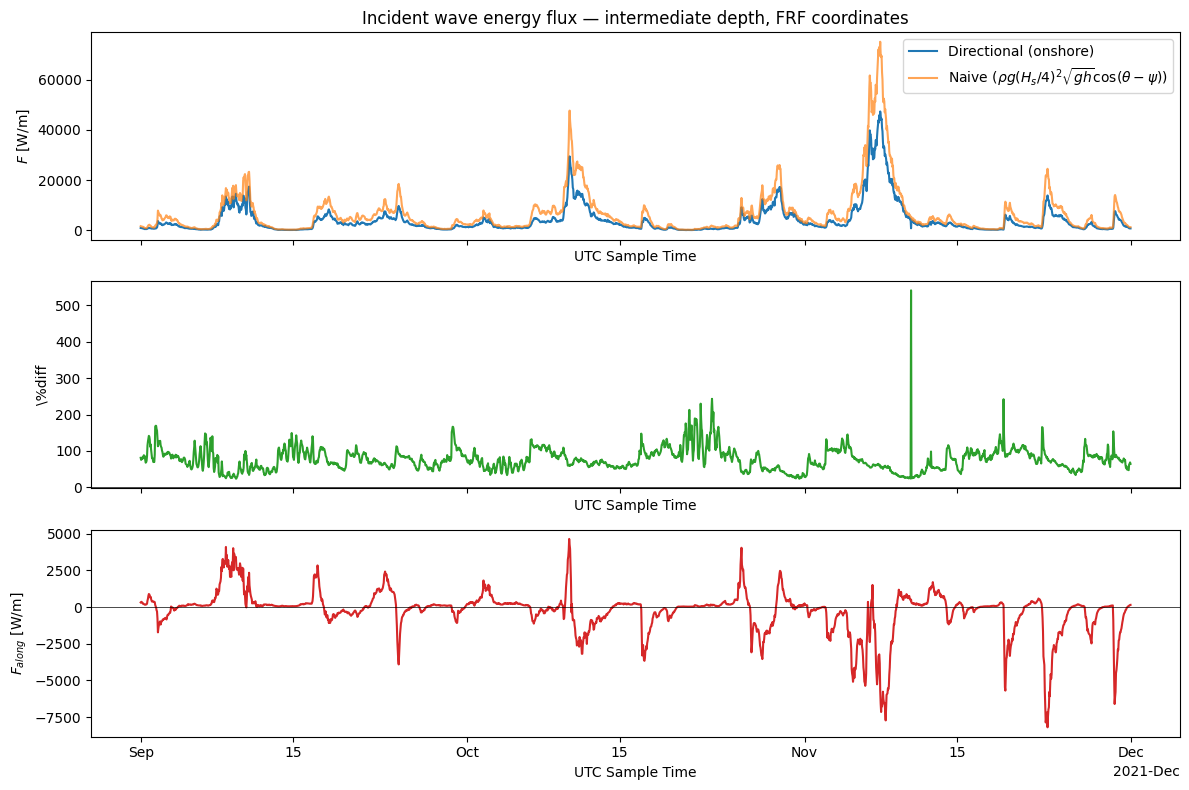

In [ ]:
from scipy.optimize import newton

rho = 1025.0
g   = 9.81
cross_shore_angle = 71.8  # degrees CW from true North — FRF offshore direction

# --- Solve dispersion relation omega^2 = g*k*tanh(k*h) via Newton's method ---
omega_vals = (2 * np.pi * wave_ds.waveFrequency).values  # (n_freq,)
h_vals     = wave_ds.depth.values                         # (n_time,)

omega_2d = omega_vals[np.newaxis, :]                                     # (1, n_freq)
h_2d     = h_vals[:, np.newaxis]                                         # (n_time, 1)
k0       = omega_2d**2 / g * np.ones((len(h_vals), len(omega_vals)))    # (n_time, n_freq)

k_np = newton(
    func   = lambda k: omega_2d**2 - g * k * np.tanh(k * h_2d),
    x0     = k0,
    fprime = lambda k: -g * (np.tanh(k * h_2d) + k * h_2d / np.cosh(k * h_2d)**2),
)

k = xr.DataArray(k_np, dims=['time', 'waveFrequency'],
                 coords={'time': wave_ds.time, 'waveFrequency': wave_ds.waveFrequency})

omega = 2 * np.pi * wave_ds.waveFrequency
kh    = k * wave_ds.depth
c_p   = omega / k                                   # phase velocity [m/s]
c_g   = 0.5 * c_p * (1 + 2 * kh / np.sinh(2 * kh))  # group velocity [m/s]

# --- 2D directional energy flux ---
# S(f,theta): m^2 s deg^-1, waveDirectionBins in degrees, MET convention (from true North, CW)
E_fd           = wave_ds.directionalWaveEnergyDensity
theta_bins_rad = np.deg2rad(wave_ds.waveDirectionBins)

# Propagation unit vector for MET "coming from" convention: traveling toward theta + 180°
n_east  = -np.sin(theta_bins_rad)   # East
n_north = -np.cos(theta_bins_rad)   # North

F_east  = (rho * g * E_fd * c_g * n_east ).integrate('waveFrequency').integrate('waveDirectionBins')
F_north = (rho * g * E_fd * c_g * n_north).integrate('waveFrequency').integrate('waveDirectionBins')

# --- Project onto FRF coordinates ---
# cross-shore axis: 71.8° CW from North (seaward); positive F_cross = offshore
# along-shore axis: 71.8°-90° = -18.2° CW from North (~NNW, up-coast)
shore_normal_rad       = np.deg2rad(cross_shore_angle)
F_cross   = F_east * np.sin(shore_normal_rad) + F_north * np.cos(shore_normal_rad)      # [W/m], + = offshore
F_along   = F_east * (-np.cos(shore_normal_rad)) + F_north * np.sin(shore_normal_rad)   # [W/m], + = up-coast
F_onshore = -F_cross                                          # [W/m], + = incident/onshore

# --- Naive estimate: E = rho*g*(Hs/4)^2, c_g = sqrt(g*h) (shallow water), projected onto onshore axis ---
# waveMeanDirection: MET convention (degrees CW from North, "coming from")
# Onshore projection: dot(travel_vec, onshore_vec) = cos(theta_rad - shore_normal_rad)
theta_rad = np.deg2rad(wave_ds.waveMeanDirection)
F_naive   = rho * g * (wave_ds.waveHs / 4)**2 * np.sqrt(g * 8) * np.cos(theta_rad - shore_normal_rad)  # [W/m]

print(f"Mean onshore flux (directional):  {float(F_onshore.mean()):.1f} W/m")
print(f"Mean along-shore flux:            {float(F_along.mean()):.1f} W/m")
print(f"Mean naive flux:                  {float(F_naive.mean()):.1f} W/m")

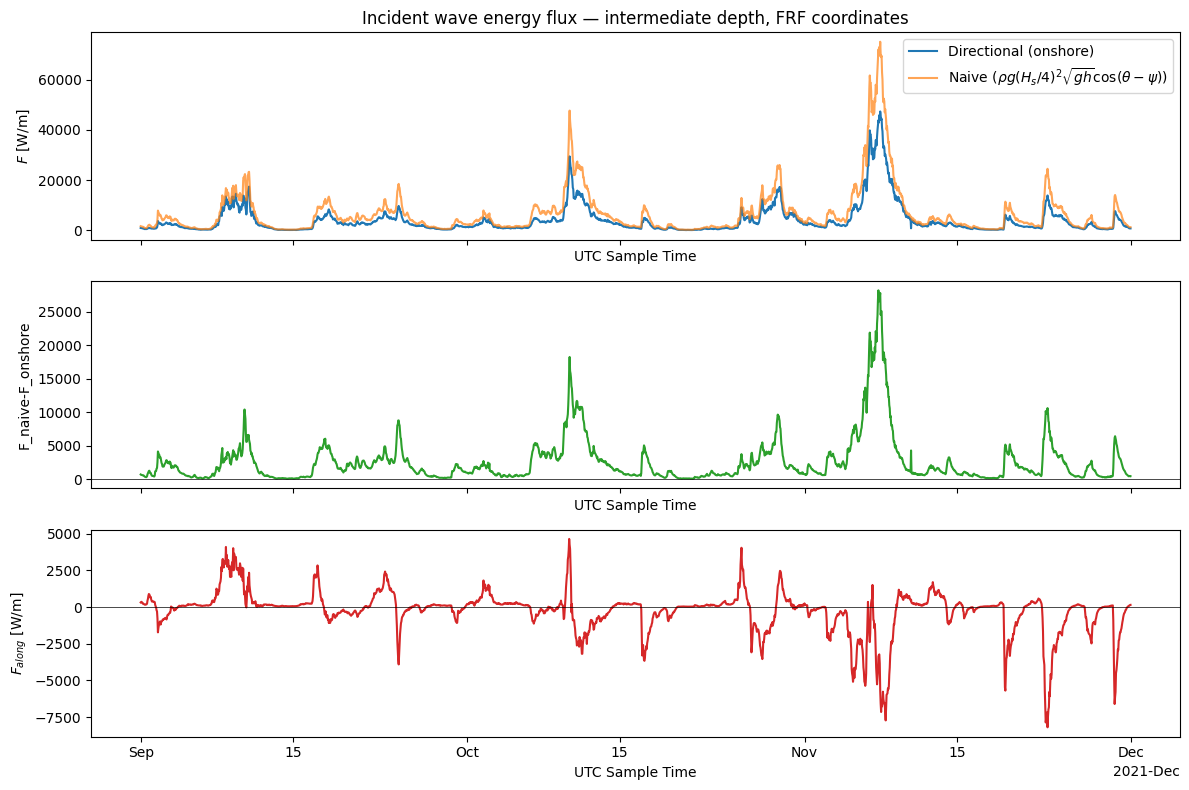

In [24]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

F_onshore.plot(ax=axes[0], label='Directional (onshore)')
F_naive.plot(ax=axes[0], label='Naive ($\\rho g (H_s/4)^2 \\sqrt{gh} \\cos(\\theta - \\psi)$)', alpha=0.7)
axes[0].set_ylabel('$F$ [W/m]')
axes[0].legend()

(F_naive-F_onshore).plot(ax=axes[1], color='C2')
axes[1].axhline(0, color='k', lw=0.5)
axes[1].set_ylabel('F_naive-F_onshore')

F_along.plot(ax=axes[2], color='C3')
axes[2].axhline(0, color='k', lw=0.5)
axes[2].set_ylabel('$F_{along}$ [W/m]')

axes[0].set_title('Incident wave energy flux — intermediate depth, FRF coordinates')
plt.tight_layout()